# Step 8 — Historical Backfill QA

Verifies the 1982–2024 GOA backfill:
1. Row-count summary per year (~365 expected)
2. Blob event 2014–2016: elevated `area_frac` and `Cbar`
3. Percentile distribution histograms for each metric
4. Regime-conditioned box plots (AO± × PDO±)

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches

ROOT = Path('..')
df = pd.read_parquet(ROOT / 'data/derived/aggregates_region/region_daily_goa.parquet')
df['date'] = pd.to_datetime(df['date'])
df['year'] = df['date'].dt.year

print(f"Total rows  : {len(df):,}")
print(f"Date range  : {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Years       : {df['year'].nunique()}  ({df['year'].min()}–{df['year'].max()})")

Total rows  : 15,706
Date range  : 1982-01-01 → 2024-12-31
Years       : 43  (1982–2024)


## 1. Row-count summary per year

In [2]:
by_year = df.groupby('year').agg(
    rows        = ('date',      'count'),
    max_af      = ('area_frac', 'max'),
    mean_af     = ('area_frac', 'mean'),
    event_days  = ('area_frac', lambda x: (x > 0.05).sum()),
    max_Ibar    = ('Ibar',      'max'),
    max_Cbar    = ('Cbar',      'max'),
).round(4)

print(f"Years with full 365/366 rows : {(by_year['rows'] >= 365).sum()}")
print(f"Years with < 365 rows        : {(by_year['rows'] < 365).sum()}  "
      f"(partial cache at ERDDAP for recent data)")
print()
print(by_year.to_string())

Years with full 365/366 rows : 43
Years with < 365 rows        : 0  (partial cache at ERDDAP for recent data)

      rows  max_af  mean_af  event_days  max_Ibar   max_Cbar
year                                                        
1982   365  0.0267   0.0016           0    1.4300   3.457400
1983   365  0.1968   0.0309          87    1.1344   8.284300
1984   366  0.1815   0.0370         103    1.0844   5.622500
1985   365  0.2025   0.0190          43    0.9881   9.511000
1986   365  0.2542   0.0250          51    0.6698   7.649000
1987   365  0.1936   0.0286          81    0.8988   8.435900
1988   366  0.0657   0.0031           6    1.7862  38.739799
1989   365  0.1060   0.0054          13    0.9142   4.212400
1990   365  0.1152   0.0048          10    1.1924   5.347000
1991   365  0.0356   0.0020           0    1.0542   7.211000
1992   366  0.0241   0.0011           0    0.6970   5.507600
1993   365  0.1477   0.0136          32    0.8848   9.999100
1994   365  0.1417   0.0069        

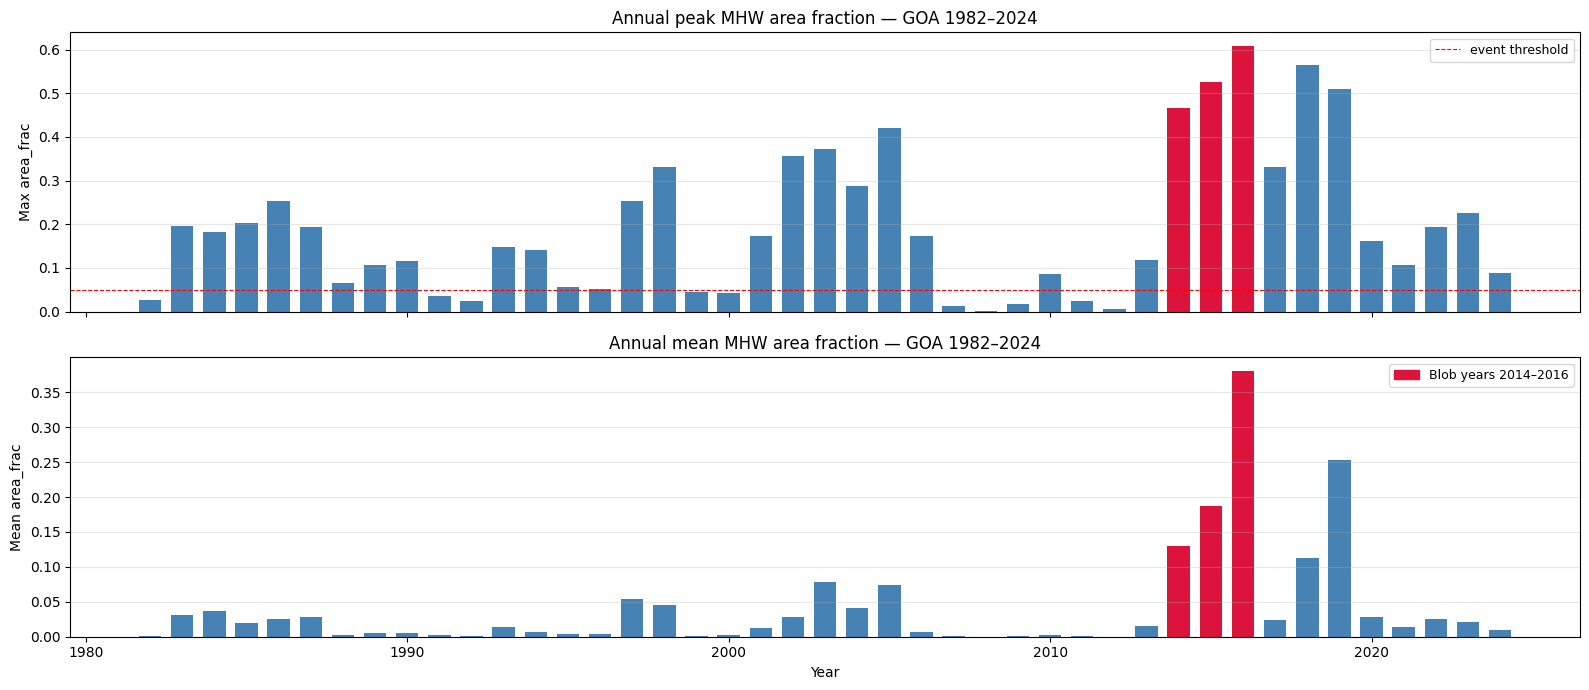

In [3]:
# Visual bar chart of annual max area_frac
fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True)

colors = ['crimson' if y in (2014, 2015, 2016) else 'steelblue' for y in by_year.index]

axes[0].bar(by_year.index, by_year['max_af'], color=colors, width=0.7)
axes[0].set_ylabel('Max area_frac')
axes[0].set_title('Annual peak MHW area fraction — GOA 1982–2024')
axes[0].axhline(0.05, color='red', linestyle='--', linewidth=0.8, label='event threshold')
axes[0].legend(fontsize=9)
axes[0].grid(axis='y', alpha=0.3)

axes[1].bar(by_year.index, by_year['mean_af'], color=colors, width=0.7)
axes[1].set_ylabel('Mean area_frac')
axes[1].set_title('Annual mean MHW area fraction — GOA 1982–2024')
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_xlabel('Year')

blob_patch = mpatches.Patch(color='crimson', label='Blob years 2014–2016')
axes[1].legend(handles=[blob_patch], fontsize=9)

fig.tight_layout()
plt.show()

## 2. Blob event 2014–2016: elevated area_frac and Cbar

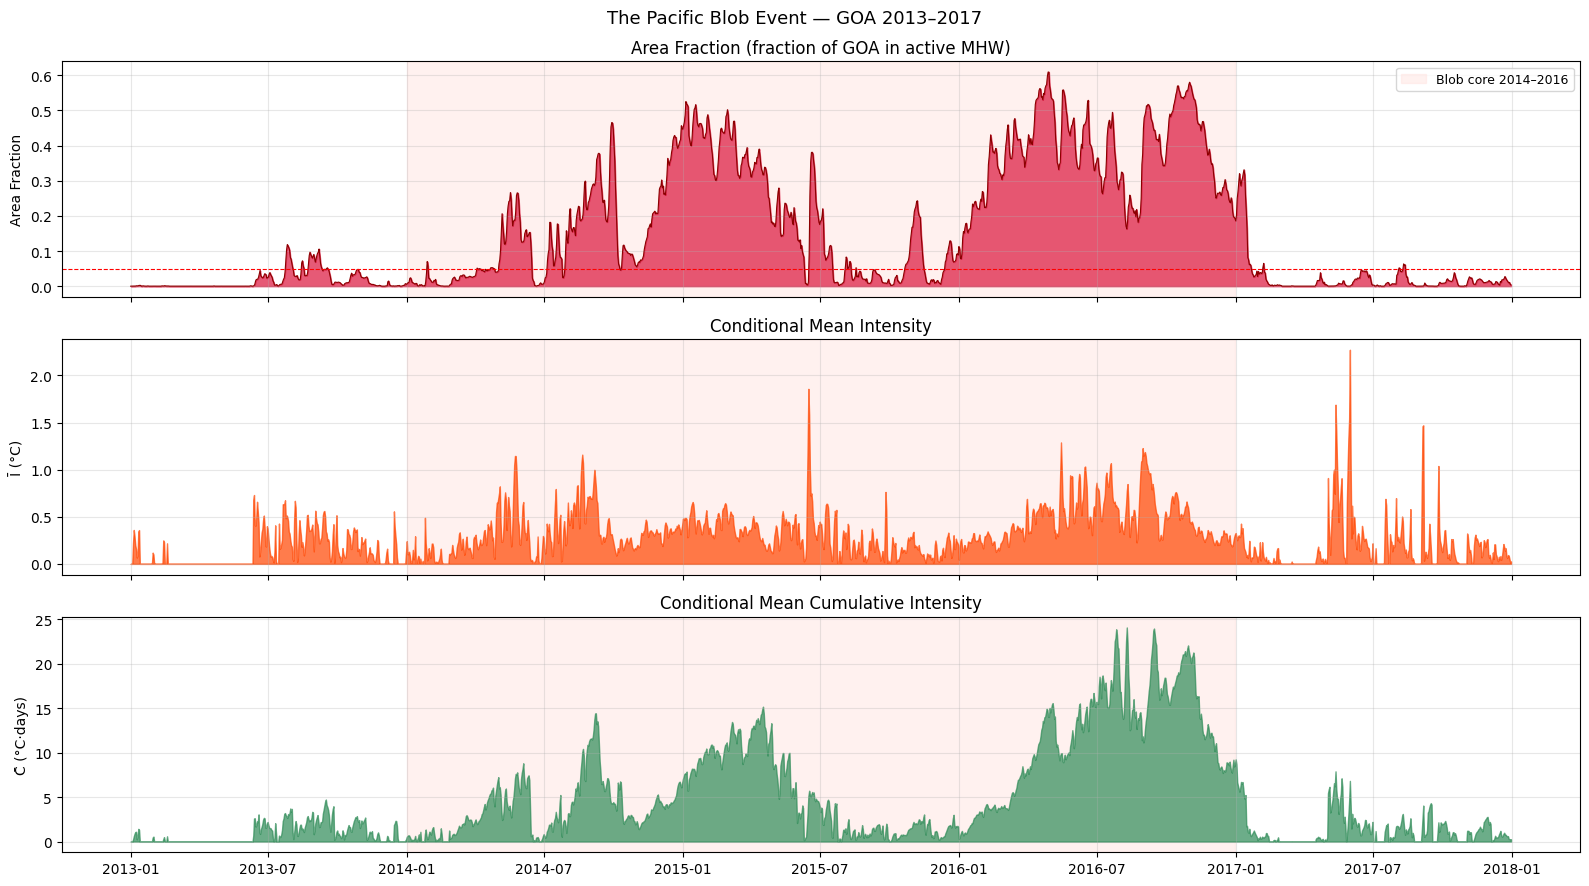


Blob core 2014–2016 vs full record:
  area_frac : blob_mean=0.2330  baseline_mean=0.0260  ratio=9.0×
  Ibar      : blob_mean=0.3600  baseline_mean=0.1252  ratio=2.9×
  Cbar      : blob_mean=6.9139  baseline_mean=1.2931  ratio=5.3×


In [4]:
# Blob period: 2013-01-01 to 2017-12-31 for context
blob = df[(df['year'] >= 2013) & (df['year'] <= 2017)].copy()

fig, axes = plt.subplots(3, 1, figsize=(16, 9), sharex=True)
fig.suptitle('The Pacific Blob Event — GOA 2013–2017', fontsize=13)

# Shade the blob core years
for ax in axes:
    ax.axvspan(pd.Timestamp('2014-01-01'), pd.Timestamp('2016-12-31'),
               color='mistyrose', alpha=0.5, label='Blob core 2014–2016')
    ax.grid(alpha=0.3)

axes[0].fill_between(blob['date'], blob['area_frac'], alpha=0.7, color='crimson')
axes[0].plot(blob['date'], blob['area_frac'], color='darkred', linewidth=0.8)
axes[0].set_ylabel('Area Fraction')
axes[0].set_title('Area Fraction (fraction of GOA in active MHW)')
axes[0].axhline(0.05, color='red', linestyle='--', linewidth=0.8)

axes[1].fill_between(blob['date'], blob['Ibar'], alpha=0.7, color='orangered')
axes[1].set_ylabel('Ī (°C)')
axes[1].set_title('Conditional Mean Intensity')

axes[2].fill_between(blob['date'], blob['Cbar'], alpha=0.7, color='seagreen')
axes[2].set_ylabel('C̄ (°C·days)')
axes[2].set_title('Conditional Mean Cumulative Intensity')
axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))

axes[0].legend(fontsize=9)
fig.tight_layout()
plt.show()

# Quantitative confirmation
print('\nBlob core 2014–2016 vs full record:')
blob_core = df[df['year'].isin([2014, 2015, 2016])]
baseline  = df[~df['year'].isin([2014, 2015, 2016])]
for col in ['area_frac', 'Ibar', 'Cbar']:
    b_mean = blob_core[col].mean()
    r_mean = baseline[col].mean()
    mult   = b_mean / r_mean if r_mean > 0 else float('inf')
    print(f"  {col:10s}: blob_mean={b_mean:.4f}  baseline_mean={r_mean:.4f}  ratio={mult:.1f}×")

## 3. Percentile distribution histograms

In [5]:
# Load risk table to get pre-computed percentile ranks
risk_df = pd.read_parquet(ROOT / 'data/derived/risk/risk_goa.parquet')
risk_df['date'] = pd.to_datetime(risk_df['date'])
risk_df['year'] = risk_df['date'].dt.year

print(f"Risk table rows : {len(risk_df):,}")
print(risk_df.describe().round(2))

Risk table rows : 15,706
                      date  area_frac_pct  Ibar_pct  Dbar_pct  Cbar_pct  \
count                15706       15706.00  15706.00  15706.00  15706.00   
mean   2003-07-02 12:00:00          50.00     50.00     50.00     50.00   
min    1982-01-01 00:00:00          18.24     22.66     18.24     22.66   
25%    1992-10-01 06:00:00          18.24     22.66     18.24     22.66   
50%    2003-07-02 12:00:00          50.00     50.00     50.00     50.00   
75%    2014-04-01 18:00:00          75.00     75.00     75.00     75.00   
max    2024-12-31 00:00:00         100.00    100.00    100.00    100.00   
std                    NaN          28.16     27.49     28.16     27.49   

       composite_risk      year  
count        15706.00  15706.00  
mean            50.00   2003.00  
min             19.79   1982.00  
25%             19.79   1992.00  
50%             53.57   2003.00  
75%             72.33   2014.00  
max             98.71   2024.00  
std             26.34     1

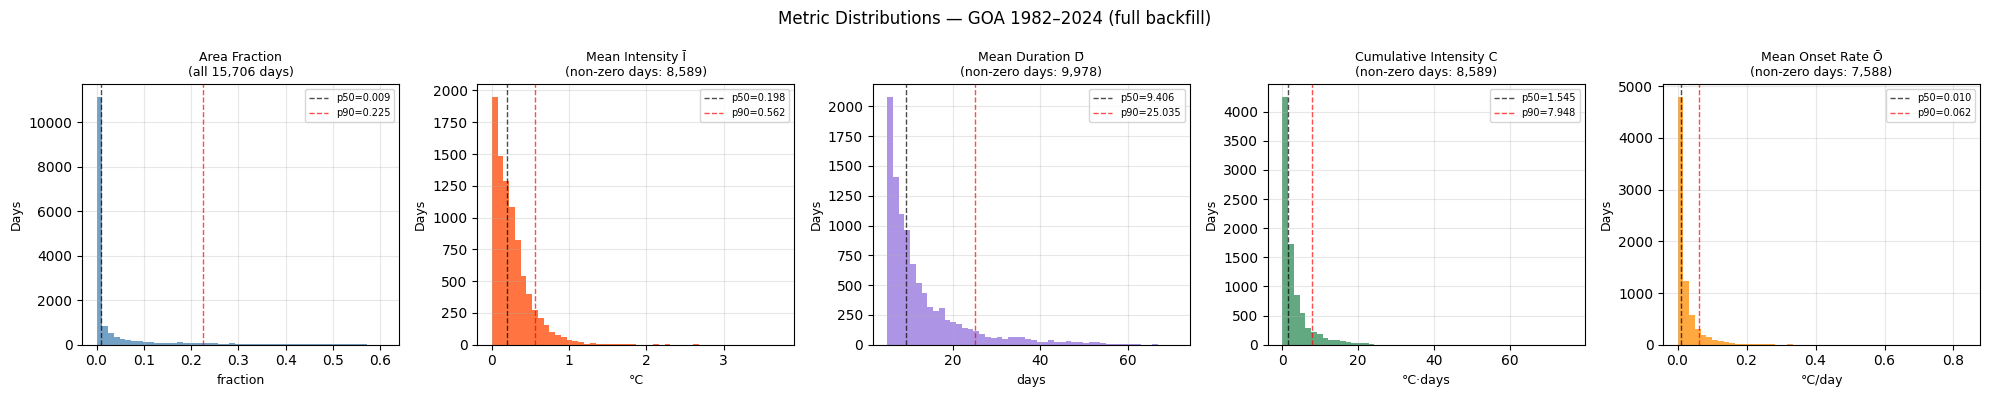

In [6]:
metrics = [
    ('area_frac', 'Area Fraction',               'fraction',  'steelblue'),
    ('Ibar',      'Mean Intensity Ī',            '°C',        'orangered'),
    ('Dbar',      'Mean Duration D̄',            'days',      'mediumpurple'),
    ('Cbar',      'Cumulative Intensity C̄',     '°C·days',   'seagreen'),
    ('Obar',      'Mean Onset Rate Ō',           '°C/day',    'darkorange'),
]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))
fig.suptitle('Metric Distributions — GOA 1982–2024 (full backfill)', fontsize=12)

for ax, (col, label, unit, color) in zip(axes, metrics):
    vals = df[col].values
    n_zero = (vals == 0).sum()
    n_pos  = (vals > 0).sum()
    
    # Only non-zero values in histogram for conditional metrics
    if col != 'area_frac':
        ax.hist(vals[vals > 0], bins=50, color=color, alpha=0.75, edgecolor='none')
        ax.set_title(f'{label}\n(non-zero days: {n_pos:,})', fontsize=9)
    else:
        ax.hist(vals, bins=50, color=color, alpha=0.75, edgecolor='none')
        ax.set_title(f'{label}\n(all {len(vals):,} days)', fontsize=9)
    
    ax.set_xlabel(unit, fontsize=9)
    ax.set_ylabel('Days', fontsize=9)
    ax.grid(alpha=0.3)
    
    p50 = np.percentile(vals[vals > 0], 50) if n_pos > 0 else 0
    p90 = np.percentile(vals[vals > 0], 90) if n_pos > 0 else 0
    ax.axvline(p50, color='black', linestyle='--', linewidth=1, alpha=0.7, label=f'p50={p50:.3f}')
    ax.axvline(p90, color='red',   linestyle='--', linewidth=1, alpha=0.7, label=f'p90={p90:.3f}')
    ax.legend(fontsize=7)

fig.tight_layout()
plt.show()

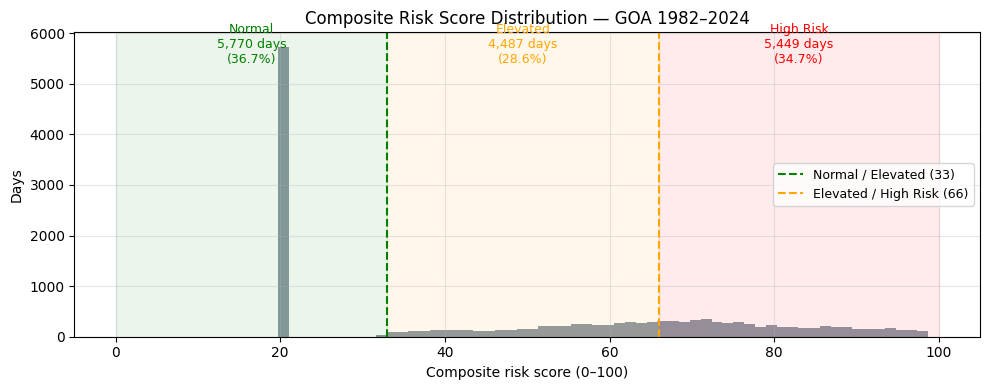

In [7]:
# Composite risk score distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(risk_df['composite_risk'], bins=60, color='slategray', alpha=0.8, edgecolor='none')

# Risk level boundaries
ax.axvline(33, color='green',  linestyle='--', linewidth=1.5, label='Normal / Elevated (33)')
ax.axvline(66, color='orange', linestyle='--', linewidth=1.5, label='Elevated / High Risk (66)')

for lo, hi, color, label in [(0, 33, 'green', 'Normal'), (33, 66, 'orange', 'Elevated'), (66, 100, 'red', 'High Risk')]:
    n = ((risk_df['composite_risk'] >= lo) & (risk_df['composite_risk'] < hi)).sum()
    pct = 100 * n / len(risk_df)
    ax.axvspan(lo, hi, alpha=0.08, color=color)
    ax.text((lo + hi) / 2, ax.get_ylim()[1] * 0.9 if ax.get_ylim()[1] > 0 else 10,
            f'{label}\n{n:,} days\n({pct:.1f}%)', ha='center', fontsize=9, color=color)

ax.set_xlabel('Composite risk score (0–100)')
ax.set_ylabel('Days')
ax.set_title('Composite Risk Score Distribution — GOA 1982–2024')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
fig.tight_layout()
plt.show()

## 4. Regime-conditioned box plots (AO± × PDO±)

In [8]:
# Load AO (daily) and PDO (monthly)
ao  = pd.read_parquet(ROOT / 'data/raw/ao_daily.parquet')
pdo = pd.read_parquet(ROOT / 'data/raw/pdo_monthly.parquet')

ao['date']  = pd.to_datetime(ao['date'])
pdo['date'] = pd.to_datetime(pdo['date'])
pdo['year_month'] = pdo['date'].dt.to_period('M')

# Merge: daily aggregates ← AO (daily)
merged = df.merge(ao[['date', 'ao']], on='date', how='inner')

# Merge: ← PDO (monthly, join on year-month)
merged['year_month'] = merged['date'].dt.to_period('M')
merged = merged.merge(pdo[['year_month', 'pdo']], on='year_month', how='left')

print(f"Rows after merge: {len(merged):,}  "
      f"(AO coverage: {merged['ao'].notna().sum():,}, "
      f"PDO coverage: {merged['pdo'].notna().sum():,})")

# Regime labels
regime_rows = merged.dropna(subset=['ao', 'pdo']).copy()
regime_rows['ao_phase']  = np.where(regime_rows['ao']  >= 0, 'AO+', 'AO−')
regime_rows['pdo_phase'] = np.where(regime_rows['pdo'] >= 0, 'PDO+', 'PDO−')
regime_rows['regime']    = regime_rows['ao_phase'] + ' / ' + regime_rows['pdo_phase']

regime_counts = regime_rows['regime'].value_counts()
print('\nDays per regime:')
print(regime_counts.to_string())

Rows after merge: 317  (AO coverage: 317, PDO coverage: 317)

Days per regime:
regime
AO+ / PDO−    173
AO− / PDO−    144


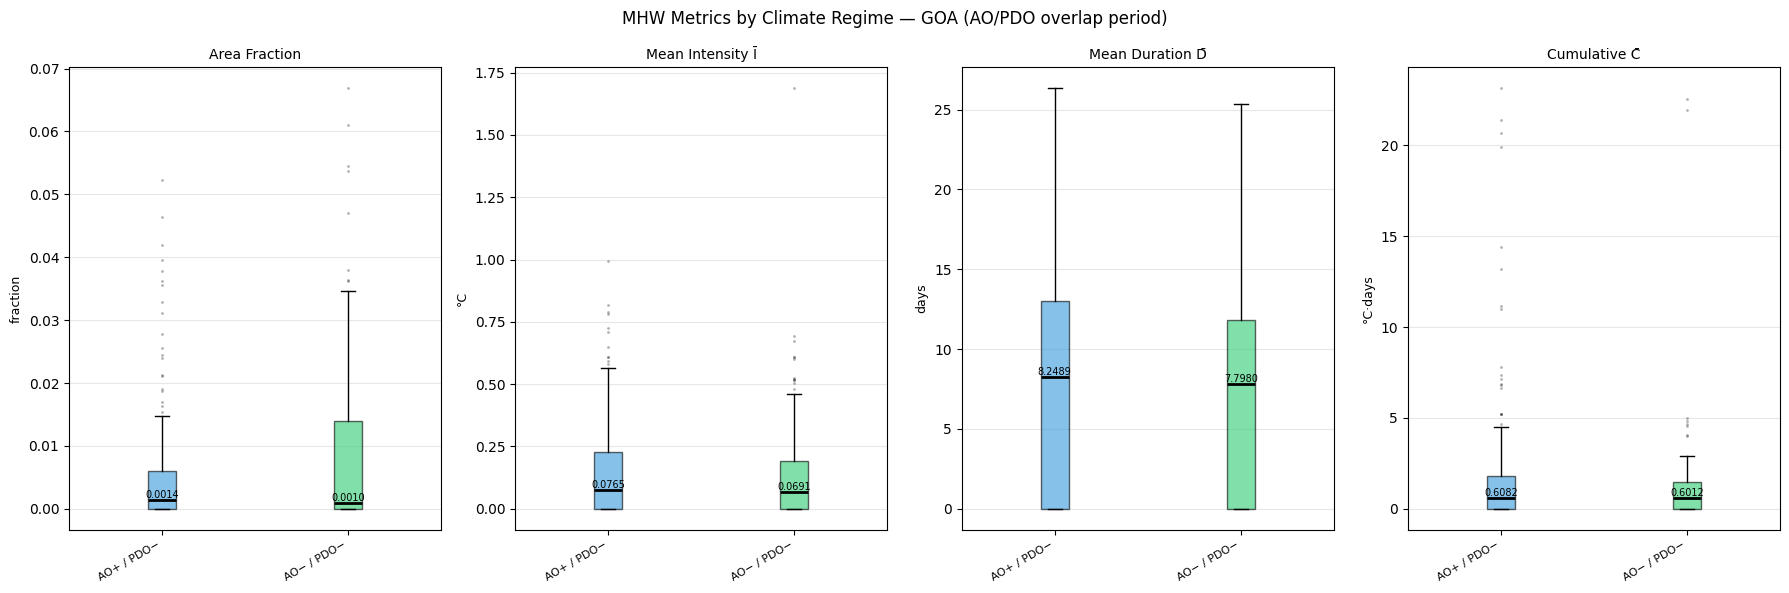


Median area_frac by regime:
  AO+ / PDO−        : median=0.00142  n=173 days  event_days(>0.05)=1
  AO− / PDO−        : median=0.00099  n=144 days  event_days(>0.05)=4


In [9]:
REGIME_ORDER  = ['AO+ / PDO+', 'AO+ / PDO−', 'AO− / PDO+', 'AO− / PDO−']
REGIME_COLORS = {'AO+ / PDO+': '#e74c3c', 'AO+ / PDO−': '#3498db',
                 'AO− / PDO+': '#e67e22', 'AO− / PDO−': '#2ecc71'}

plot_metrics = [
    ('area_frac', 'Area Fraction',        'fraction'),
    ('Ibar',      'Mean Intensity Ī',     '°C'),
    ('Dbar',      'Mean Duration D̄',     'days'),
    ('Cbar',      'Cumulative C̄',        '°C·days'),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 6))
fig.suptitle('MHW Metrics by Climate Regime — GOA (AO/PDO overlap period)',
             fontsize=12)

for ax, (col, label, unit) in zip(axes, plot_metrics):
    groups = [regime_rows.loc[regime_rows['regime'] == r, col].values
              for r in REGIME_ORDER if r in regime_rows['regime'].values]
    labels = [r for r in REGIME_ORDER if r in regime_rows['regime'].values]
    colors = [REGIME_COLORS[r] for r in labels]
    
    bp = ax.boxplot(groups, patch_artist=True, notch=False,
                    medianprops={'color': 'black', 'linewidth': 2},
                    flierprops={'marker': '.', 'markersize': 2, 'alpha': 0.3})
    for patch, color in zip(bp['boxes'], colors):
        patch.set_facecolor(color)
        patch.set_alpha(0.6)
    
    ax.set_xticks(range(1, len(labels) + 1))
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
    ax.set_ylabel(unit, fontsize=9)
    ax.set_title(label, fontsize=10)
    ax.grid(axis='y', alpha=0.3)
    
    # Annotate medians
    for i, g in enumerate(groups):
        if len(g) > 0:
            med = np.median(g)
            ax.text(i + 1, med, f'{med:.4f}', ha='center', va='bottom',
                    fontsize=7, color='black')

fig.tight_layout()
plt.show()

# Print regime medians
print('\nMedian area_frac by regime:')
for r in REGIME_ORDER:
    subset = regime_rows[regime_rows['regime'] == r]
    if len(subset):
        print(f"  {r:18s}: median={subset['area_frac'].median():.5f}  "
              f"n={len(subset):,} days  "
              f"event_days(>0.05)={(subset['area_frac']>0.05).sum()}")

## 5. Full time-series overview (1982–2024)

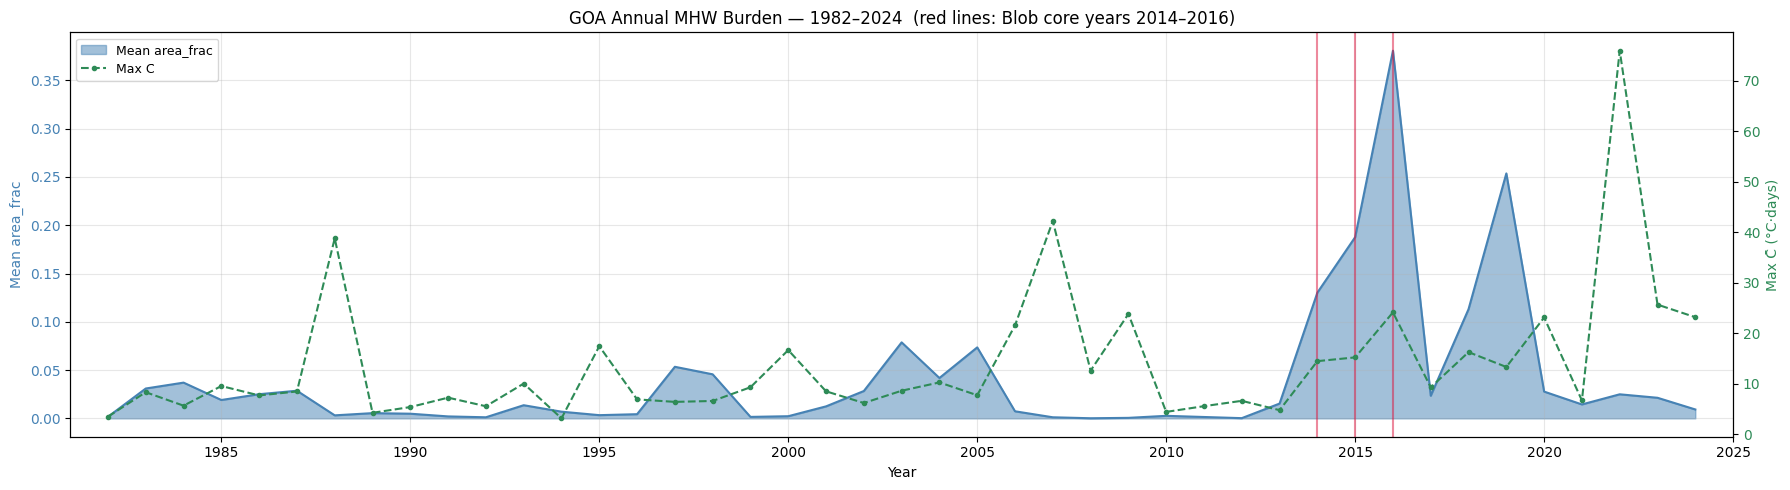

In [10]:
# Annual mean area_frac vs annual max Cbar overlay
fig, ax1 = plt.subplots(figsize=(18, 5))

ax2 = ax1.twinx()

ax1.fill_between(by_year.index, by_year['mean_af'], alpha=0.5, color='steelblue', label='Mean area_frac')
ax1.plot(by_year.index, by_year['mean_af'], color='steelblue', linewidth=1.5)
ax1.set_ylabel('Mean area_frac', color='steelblue', fontsize=10)
ax1.tick_params(axis='y', labelcolor='steelblue')

ax2.plot(by_year.index, by_year['max_Cbar'], color='seagreen', linewidth=1.5,
         linestyle='--', marker='o', markersize=3, label='Max C̄')
ax2.set_ylabel('Max C̄ (°C·days)', color='seagreen', fontsize=10)
ax2.tick_params(axis='y', labelcolor='seagreen')

# Annotate blob
for yr in [2014, 2015, 2016]:
    ax1.axvline(yr, color='crimson', linewidth=1.5, alpha=0.5)

ax1.set_xlabel('Year')
ax1.set_title('GOA Annual MHW Burden — 1982–2024  (red lines: Blob core years 2014–2016)')
ax1.grid(alpha=0.3)
ax1.set_xlim(1981, 2025)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')

fig.tight_layout()
plt.show()